
# **WCGAN (Deep Convolutional GAN)**



## **O Problema Fundamental das GANs Tradicionais**

As GANs tradicionais, propostas por Goodfellow et al., funcionam como um jogo de dois jogadores: um Gerador (que cria dados falsos) e um Discriminador (que tenta distinguir dados reais dos falsos) . O discriminador tradicional é um classificador binário que retorna uma probabilidade (um valor entre 0 e 1) de uma amostra ser real. O gerador é treinado para maximizar a probabilidade de o discriminador se enganar.

Na prática, treinar GANs é notoriamente difícil devido a dois problemas principais :

* **Desvanecimento do Gradiente (Vanishing Gradient):** Se o discriminador se tornar muito bom rapidamente, ele consegue classificar as imagens falsas com quase 100% de certeza. Nesse cenário, a função de perda (loss) do gerador satura e seu gradiente se aproxima de zero, fazendo com que ele pare de aprender .

*  **Colapso de Modos (Mode Collapse):** O gerador encontra um pequeno número de amostras que "enganam" o discriminador e passa a gerar apenas essas variações, perdendo a capacidade de gerar a diversidade total dos dados reais .

A causa raiz desses problemas está na função de perda. Obtém-se a prova de que, quando o discriminador é treinado até a otimalidade, o gerador está, na verdade, minimizando a Divergência de Jensen-Shannon (JS) entre a distribuição dos dados reais e a dos dados gerados . O problema é que a divergência JS não é contínua e seu gradiente pode desaparecer quando as distribuições não têm sobreposição significativa, o que é comum no início do treinamento

.


## **O Conceito Central da WGAN: A Distância de Wasserstein**
A WGAN, introduzida por Arjovsky et al. em 2017, propõe uma mudança fundamental para resolver esses problemas: substituir a divergência JS pela Distância de Wasserstein, também conhecida como Earth-Mover (EM) Distance .

Intuição: Imagine que você tem duas pilhas de terra (distribuições de probabilidade) e quer transformar uma na outra. A distância de Wasserstein é o custo mínimo para mover a terra de uma pilha para a outra, onde o custo é a quantidade de terra movida multiplicada pela distância percorrida .

Essa métrica possui propriedades muito mais vantajosas para o treinamento:

* **Continuidade e Diferencialidade:** A distância de Wasserstein é contínua e diferenciável em quase toda parte, mesmo quando as distribuições não se sobrepõem. Isso garante que o gerador sempre receba um gradiente útil para aprender, mitigando o problema do desvanecimento .

* **Correlação com a Qualidade:**  A perda da WGAN é um valor significativo que se correlaciona bem com a qualidade das imagens geradas. Quanto menor a perda, melhores tendem a ser as imagens, o que não acontece na GAN tradicional .

#  **Como a WGAN Funciona na Prática:O Crítico e a Continuidade de Lipschitz**

Para usar a distância de Wasserstein, que é computacionalmente intratável em sua forma original, a WGAN faz duas grandes alterações na arquitetura :

* **O Discriminador vira um Crítico:** A rede que antes era um discriminador (classificador binário com saída sigmoide) é transformada em um crítico. O crítico não classifica, mas sim retorna um valor escalar sem restrições (um número real qualquer), que representa quão "real" a imagem de entrada parece . Quanto maior o valor, mais real a imagem é considerada.

* **Imposição da Continuidade de Lipschitz (1-Lipschitz):**  Para que a fórmula simplificada da distância de Wasserstein funcione, a função aprendida pelo crítico precisa ser 1-Lipschitz. Isso significa que a inclinação (gradiente) da função deve ser, no máximo, 1 em qualquer ponto . Em outras palavras, a função não pode mudar muito abruptamente.

Para forçar essa restrição, a WGAN original utiliza uma técnica simples, mas imperfeita, chamada Weight Clipping: após cada atualização, os pesos do crítico são "cortados" para que fiquem dentro de um pequeno intervalo, como **[-0.01, 0.01]**


# **Importacao das bibliotecas**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras  import layers

# **Importacao das bases de dados**

In [ ]:
#Carregamento base de dados FASHIONMNIST
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [ ]:
(X_treinamento,y_teste), (y_treinamento,y_teste) = tf.keras.datasets.mnist.load_data()

In [ ]:
# Temos 60000 imagens cada uma delas com resolução 28x28, portanto, 784 pixels
X_treinamento.shape

(60000, 28, 28)

In [ ]:
num_total_imagem, num_pixles_x, num_pixles_y = X_treinamento.shape

In [ ]:
num_total_imagem, num_pixles_x, num_pixles_y

(60000, 28, 28)

## **Visualizando as imagens da base de dados.**



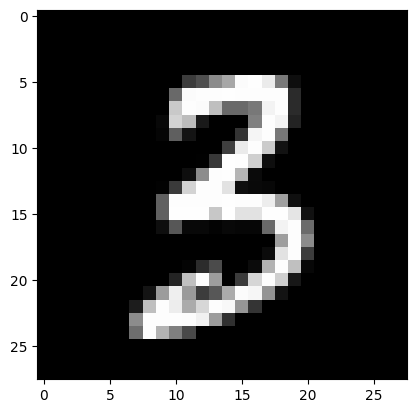

In [ ]:
index_imagem = np.random.randint(0,60000)
plt.imshow(X_treinamento[index_imagem ],cmap ='gray')

# **Pré processamento da base de dados**

In [ ]:
#Adequando a base de treinamento indicando o numero de canal de cores

# num_total_imagem  = numero total de imagens
# num_pixles_x  = numero de pixels em x
# num_pixles_y = numero de pixels em y

X_treinamento_tf = X_treinamento.reshape(num_total_imagem,num_pixles_x, num_pixles_y, 1 ).astype('float32')

In [ ]:
X_treinamento_tf.shape

(60000, 28, 28, 1)

## **Normalizando a base de dados**

In [ ]:
X_treinamento_tf[0].min(), X_treinamento_tf[0].max()

(np.float32(0.0), np.float32(255.0))

In [ ]:
X_treinamento_tf = (X_treinamento_tf-127.5)/127.5

In [ ]:
X_treinamento_tf[0].min(),X_treinamento_tf[0].max()

(np.float32(-1.0), np.float32(1.0))

In [ ]:
type(X_treinamento_tf)

numpy.ndarray

In [ ]:
buffer_size = num_total_imagem
batch_size = 256


In [ ]:
buffer_size/batch_size

234.375

In [ ]:
X_treinamento_tf = tf.data.Dataset.from_tensor_slices(X_treinamento_tf).shuffle(buffer_size).batch(batch_size)

In [ ]:
type(X_treinamento_tf)

tensorflow.python.data.ops.batch_op._BatchDataset

#**Construindo o gerador**

A seguir vamos definir  a função rede_geradora(), que constrói a arquitetura do gerador em uma GAN. O gerador recebe um vetor de **ruído latente de dimensão 100** e **produz uma imagem 28×28×1**. A arquitetura segue o padrão DCGAN, utilizando camadas densas, reshape e convoluções transpostas para aumentar progressivamente a resolução espacial.

In [ ]:
def rede_geradora():

  rede_neural_geradora = tf.keras.Sequential()

  # Camada de entrada
  # Transforma o vetor latente de tamanho 100 em um vetor de 12544 elementos (7×7×256).

  rede_neural_geradora.add(layers.Dense(units =7*7*256, use_bias=False, input_shape =(100,)))

  #BatchNorm normaliza as ativações, estabilizando o treinamento.
  rede_neural_geradora.add(layers.BatchNormalization())

 #LeakyReLU permite pequenos gradientes negativos, evitando desligados mortos
  rede_neural_geradora.add(layers.LeakyReLU())

  # Redimensionalizando
  #Reformata o vetor 12544 em um volume 7×7 com 256 canais.
  rede_neural_geradora.add(layers.Reshape((7,7,256)))


  # Primeira convolução transposta (manutenção da resolução)
  rede_neural_geradora.add(layers.Conv2DTranspose(filters=128,kernel_size=(5,5),padding='same', use_bias=False ))
  rede_neural_geradora.add(layers.BatchNormalization())
  rede_neural_geradora.add(layers.LeakyReLU())

  # Segunda convolução transposta (upsampling para 14×14)
  rede_neural_geradora.add(layers.Conv2DTranspose(filters=64,kernel_size=(5,5),padding='same', strides=(2,2), use_bias=False ))
  rede_neural_geradora.add(layers.BatchNormalization())
  rede_neural_geradora.add(layers.LeakyReLU())


  #Terceira convolução transposta (upsampling para 28×28 e geração da imagem)
  rede_neural_geradora.add(layers.Conv2DTranspose(filters=1,kernel_size= (5,5),padding='same',strides=(2,2), use_bias=False, activation='tanh' ))

  rede_neural_geradora.summary()

  return rede_neural_geradora

In [ ]:
rede_neural_geradora = rede_geradora()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [ ]:
noise =tf.random.normal([1,100])

In [ ]:
imagem_gerada = rede_neural_geradora(noise, training=False)

In [ ]:
imagem_gerada.shape

TensorShape([1, 28, 28, 1])

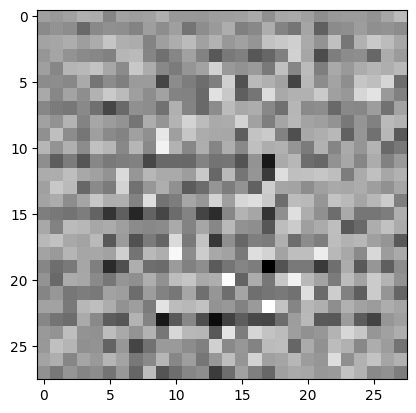

In [ ]:
plt.imshow(imagem_gerada[0,:,:,0], cmap='gray')

# **Construindo o discriminador**

O trecho de código a seguir define uma função que constrói e retorna um modelo de rede neural com uma rquitetura típica  de um disciminador em uma Rede Generativa Adversária (GAN), cujo objetivo é classificar imagens como reais ou falsas (geradas).



## **Primeiro bloco de convolução**

* Adiciona uma camada convolucional 2D com:


  * **filters=64:** produz 64 mapas de características (canais de saída).

  * **strides=(2,2):** o passo da convolução é **2** em ambas as direções, o que reduz a resolução espacial pela metade.

  * **kernel_size=(5,5)**: usa filtros de tamanho **5x5**.

  * **padding='same':** aplica padding para que a saída tenha a mesma largura/altura da entrada quando stride=1. Com stride=2, a saída será aproximadamente metade (arredondada para cima).Portanto, a saída será 14x14 (pois 28/2 = 14).

  * **input_shape=[28,28,1]:** especifica que a entrada será uma imagem de 28x28 pixels com 1 canal (escala de cinza), como as imagens do dataset MNIST.

* **Após esta camada, a saída tem dimensão (14, 14, 64).**

## **Função de ativação**

Adiciona a ativação **Leaky ReLU**, que permite um pequeno gradiente negativo (diferente do **ReLU** tradicional que zera valores negativos). Isso ajuda a evitar neurônios mortos e melhora o treinamento de GANs.

## **Dropout**

Aplica Dropout com taxa de 0.3 (30% dos neurônios são zerados aleatoriamente durante o treinamento). Isso ajuda a evitar overfitting e torna o discriminador mais robusto.

## **Camada Flatten()**
Achata o tensor 3D (7, 7, 128) em um vetor 1D de tamanho 7*7*128 = 6272, para poder conectar a uma camada densa.

## **Camada de saída**
Camada densa (fully connected) com 1 neurônio. A saída é um único valor, que será usado para classificação binária (real ou falso). Normalmente, em GANs, essa saída não tem ativação, podendo ser interpretada como logit


In [ ]:
def rede_discriminadora():

  #Cria um modelo sequencial, onde as camadas serão empilhadas uma após a outra
  rede_neural_discriminadora = tf.keras.Sequential()

  #Primeira camada convolucional
  #14x14
  rede_neural_discriminadora.add(layers.Conv2D(filters=64,strides=(2,2),kernel_size=(5,5),padding='same', input_shape =[28,28,1]))
  rede_neural_discriminadora.add(layers.LeakyReLU())
  rede_neural_discriminadora.add(layers.Dropout(0.3))

  #Segunda camada convolucional
  #7x7
  rede_neural_discriminadora.add(layers.Conv2D(filters=128,strides=(2,2),kernel_size=(5,5),padding='same',))
  rede_neural_discriminadora.add(layers.LeakyReLU())
  rede_neural_discriminadora.add(layers.Dropout(0.3))


  rede_neural_discriminadora.add(layers.Flatten())
  rede_neural_discriminadora.add(layers.Dense(1))

  rede_neural_discriminadora.summary()

  return rede_neural_discriminadora





In [ ]:
rede_neural_discriminadora = rede_discriminadora()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
7*7*128

6272

In [ ]:
rede_neural_discriminadora(imagem_gerada, training= False) #logits

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.00028099]], dtype=float32)>

In [ ]:
tf.sigmoid(-0.00029651)

<tf.Tensor: shape=(), dtype=float32, numpy=0.4999258518218994>

# **Função para o calculo de Wassertein Loss**

In [ ]:

tf.math.reduce_mean([1.0,2.0,3.0,4.0])

<tf.Tensor: shape=(), dtype=float32, numpy=2.5>

In [ ]:
(1+2+3+4)/4

2.5

In [ ]:
def loss_generator(fake_output):
  g_loss =-1.*tf.math.reduce_mean(fake_output)
  return g_loss


In [ ]:
def loss_discriminator(real_output, fake_output, gradient_penalty):
  c_lambda =10
  d_loss = tf.math.reduce_mean(fake_output) - tf.math.reduce_mean(real_output) + c_lambda*gradient_penalty
  return d_loss

## **Gradinte Penaltly**

A função gradient_penalty implementa a penalidade de gradiente usada em Wasserstein GAN com **Gradient Penalty** **(WGAN-GP)**.

Ela calcula um termo de regularização que incentiva o discriminador (crítico) a ter gradientes com norma próxima de 1 em pontos interpolados entre imagens reais e falsas, garantindo a **condição de Lipschitz** necessária para a estabilidade do treinamento.


## **Importância na WGAN-GP:**

A penalidade força o discriminador a ser 1-Lipschitz, ou seja, a magnitude da derivada em qualquer ponto não ultrapassa 1.

Isso estabiliza o treinamento, evita colapso de modos e garante que a distância de Wasserstein seja bem comportada

In [ ]:
@tf.function

def gradient_penalty(real_images, fake_images, epsilon):
  #Criação das imagens interpoladas
  interpolated_images = epsilon*real_images + (1-epsilon)*fake_images

  with tf.GradientTape() as gp_tape:
    gp_tape.watch(interpolated_images)
    scores =rede_neural_discriminadora(interpolated_images)[0]

  #Obtenção do gradiente
  gradient = gp_tape.gradient(scores, interpolated_images)[0]

  #Norma do gradiente
  gradient_norm = tf.norm(gradient)

  #Penalidade
  gp = tf.math.reduce_mean((gradient_norm-1)**2)
  return gp



##**Definição dos otimizadores**

* **learning_rate:** Define o tamanho do passo dado na direção do gradiente.
* **beta_1:** Coeficiente de decaimento para a estimativa do primeiro momento (média dos gradientes)
* **beta_2**: Coeficiente de decaimento para a estimativa do segundo momento (variância dos gradientes

In [ ]:


#Otimizado para a rede geradora
gerador_otimizadores = tf.keras.optimizers.Adam(learning_rate= 2e-4,beta_1 =0.5,beta_2=0.9)

#otimização para a rede geradora
discriminador_otimizadores = tf.keras.optimizers.Adam(learning_rate= 2e-4,beta_1 =0.5,beta_2=0.9)

In [ ]:
checkpoint_dir ='./training_checkpoints'
checkpoint_prefix =os.path.join(checkpoint_dir,"ckpt")
checkpoint = tf.train.Checkpoint(generator_optmizer =gerador_otimizadores,
                                 discriminator_optmizaer=discriminador_otimizadores,
                                 discriminator =rede_neural_discriminadora)

**Treinamento**

In [ ]:
epochs =30
noise_dimension = 100
number_of_images =16

In [ ]:
seed =tf.random.normal([number_of_images,noise_dimension])

In [ ]:
def training_step(imagens):

  # Gera um lote de ruído aleatório (vetores latentes) a partir de uma distribuição normal
  # batch_size: tamanho do lote, noise_dimension: dimensão do espaço latente (ex.: 100)
  noise = tf.random.normal([batch_size, noise_dimension])


  # Número de vezes que o discriminador será treinado antes de cada treinamento do gerador
  # Isso ajuda a manter o discriminador forte o suficiente para fornecer gradientes úteis ao gerador
  discriminator_extra_steps =3


  for i in range(discriminator_extra_steps):
     # Cria uma fita de gradiente para registrar as operações e calcular os gradientes do discriminador
      with tf.GradientTape() as disc_tape:
        # Gera imagens falsas a partir do ruído, passando training=True para ativar camadas como dropout/batch norm
        generated_images = rede_neural_geradora(noise, training=True)

        # Classifica as imagens reais (fornecidas como argumento) pelo discriminador
        real_output = rede_neural_discriminadora(imagens,training=True)

         # Classifica as imagens falsas (geradas) pelo discriminador
        fake_output = rede_neural_discriminadora(generated_images,training=True)

         # Gera valores aleatórios epsilon para interpolação entre imagens reais e falsas
        epsilon = tf.random.normal([batch_size,1,1,1],0.0,1.0)

        # Calcula a penalidade de gradiente (técnica WGAN-GP) para forçar o discriminador a ser 1-Lipschitz
        gradient_penalty_value = gradient_penalty(imagens,generated_images,epsilon)

        # Calcula a perda total do discriminador, combinando as saídas para reais e falsas com a penalidade
        d_loss =loss_discriminator(real_output,fake_output,gradient_penalty_value)


      # Calcula os gradientes da perda do discriminador em relação a todos os pesos treináveis do discriminador
      discriminator_gradients = disc_tape.gradient(d_loss, rede_neural_discriminadora.trainable_variables)
      # Aplica os gradientes para atualizar os pesos do discriminador usando seu otimizador específico
      discriminador_otimizadores.apply_gradients(zip(discriminator_gradients, rede_neural_discriminadora.trainable_variables))


  with tf.GradientTape() as gen_tape:
    # Gera novas imagens falsas (pode reutilizar o mesmo ruído ou gerar outro; aqui reutiliza)
    generated_images = rede_neural_geradora(noise, training=True)

    # Classifica as imagens geradas pelo discriminador (agora com pesos atualizados)
    fake_output = rede_neural_discriminadora(generated_images, training=True)

    # Calcula a perda do gerador: tipicamente, quanto melhor ele engana o discriminador
    g_loss = loss_generator(fake_output)

  #Calcula os gradientes da perda do gerador em relação aos pesos do gerador
  generator_gradients = gen_tape.gradient(g_loss, rede_neural_geradora.trainable_variables)

   # Aplica os gradientes para atualizar os pesos do gerador usando seu otimizador específico
  gerador_otimizadores.apply_gradients(zip(generator_gradients, rede_neural_geradora.trainable_variables))


In [ ]:
def create_and_save_images(model, epoch, test_input):
  preds = model(test_input, training = False)
  fig = plt.figure(figsize = (4,4))
  for i in range(preds.shape[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(preds[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
    plt.axis('off')
  plt.savefig('img_epoch_{:04d}'.format(epoch))
  plt.show()

In [ ]:
import time
def train(dataset, epochs):
  for epoch in range(epochs):
    initial = time.time()
    for img_batch in dataset:
      if len(img_batch) == batch_size:
        training_step(img_batch)

    create_and_save_images(rede_neural_geradora, epoch + 1, seed)
    if (epoch + 1) % 10 == 0:
      checkpoint.save(file_prefix = checkpoint_prefix)
    print('Time taken to process epoch {} was {} seconds'.format(epoch + 1, time.time() - initial))

  create_and_save_images(rede_neural_geradora, epochs, seed)
  rede_neural_geradora.save('generator.h5')

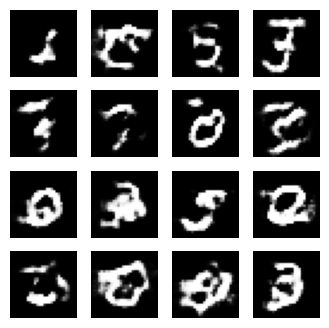

Time taken to process epoch 1 was 113.96604514122009 seconds


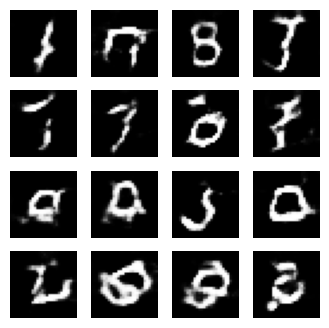

Time taken to process epoch 2 was 114.27766609191895 seconds


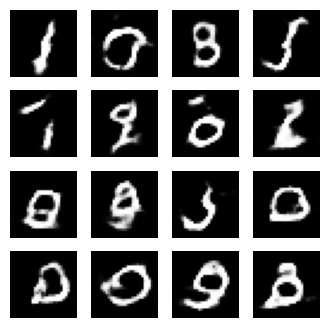

Time taken to process epoch 3 was 113.81030488014221 seconds


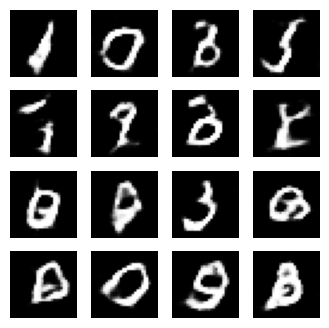

Time taken to process epoch 4 was 114.0167064666748 seconds


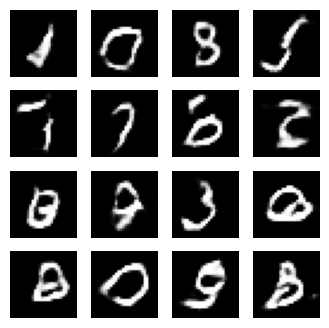

Time taken to process epoch 5 was 115.67899918556213 seconds


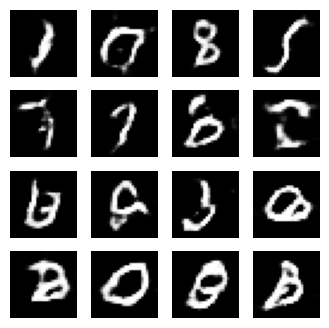

Time taken to process epoch 6 was 113.04864859580994 seconds


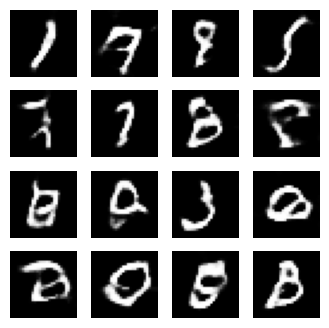

Time taken to process epoch 7 was 115.38992023468018 seconds


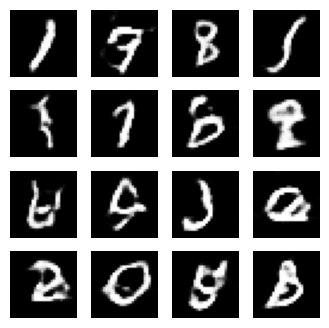

Time taken to process epoch 8 was 114.94994330406189 seconds


In [ ]:
train(X_treinamento_tf , epochs)